<a href="https://colab.research.google.com/github/AngeloSorte/CO2_Trend_Forecasting_NASAv/blob/angelosorte.github.io/CO2_Trend_Forecasting_NASA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# --- Installazioni (se necessario) ---
!pip install matplotlib pandas scikit-learn

# --- Librerie ---
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np


In [3]:
# Carica il dataset dal web direttamente
url = "https://datahub.io/core/co2-ppm/r/co2-mm-mlo.csv"
df = pd.read_csv(url)

# Controlla i primi dati
print(df.head())
print(df.info())


              Date  Decimal Date  Average  Interpolated  Trend  Number of Days
1958-03  1958.2027        315.71   314.44            -1  -9.99           -0.99
1958-04  1958.2877        317.45   315.16            -1  -9.99           -0.99
1958-05  1958.3699        317.51   314.69            -1  -9.99           -0.99
1958-06  1958.4548        317.27   315.15            -1  -9.99           -0.99
1958-07  1958.5370        315.87   315.20            -1  -9.99           -0.99
<class 'pandas.core.frame.DataFrame'>
Index: 813 entries, 1958-03 to 2025-11
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            813 non-null    float64
 1   Decimal Date    813 non-null    float64
 2   Average         813 non-null    float64
 3   Interpolated    813 non-null    int64  
 4   Trend           813 non-null    float64
 5   Number of Days  813 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 44.5+ KB
None


In [4]:
# Converti Date in datetime e poi in numero (anno.frazione)
df['Date'] = pd.to_datetime(df['Date'])
df['YearFraction'] = df['Date'].dt.year + df['Date'].dt.dayofyear/365.25

# Seleziona colonne
X = df[['YearFraction']]
y = df['Trend']  # valore CO2 interpolato sul trend

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


In [5]:
# Inizializza modello
model = LinearRegression()
model.fit(X_train, y_train)

# Previsione
y_pred = model.predict(X_test)

# Metriche
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
print(f"RMSE: {rmse:.2f}")


RMSE: 3.27


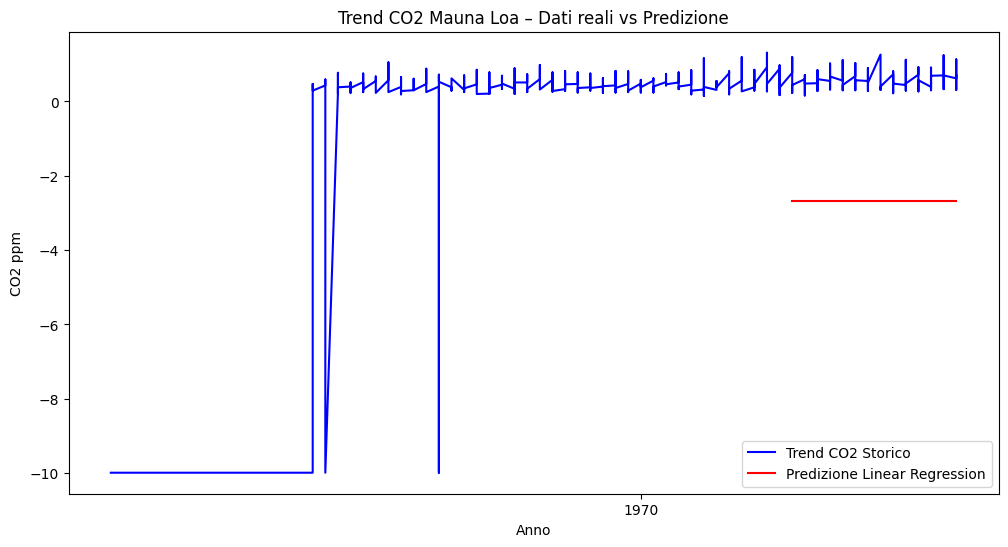

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/tmp/ipython-input-1772683530.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=last_date, periods=len(future_years), freq='M')


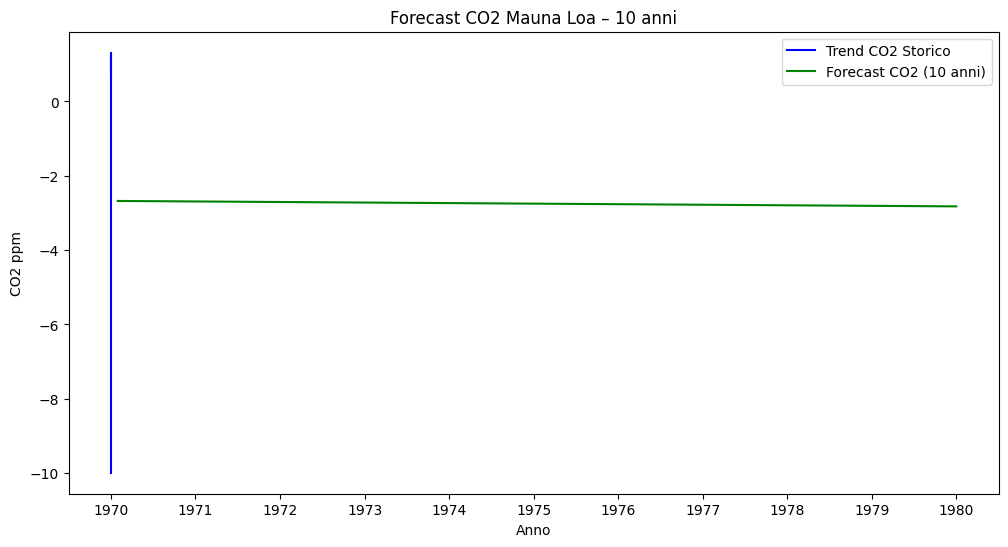

In [6]:
# Date corrispondenti al test set
test_dates = df['Date'].iloc[len(X_train):]

plt.figure(figsize=(12,6))
plt.plot(df['Date'], y, label='Trend CO2 Storico', color='blue')
plt.plot(test_dates, y_pred, label='Predizione Linear Regression', color='red')
plt.xlabel('Anno')
plt.ylabel('CO2 ppm')
plt.title('Trend CO2 Mauna Loa – Dati reali vs Predizione')
plt.legend()
plt.show()



# Forecast mensile prossimi 10 anni
last_date = df['Date'].max()
last_yearfraction = df['YearFraction'].max()

future_years = np.arange(last_yearfraction, last_yearfraction + 10, 1/12).reshape(-1,1)
future_pred = model.predict(future_years)

# Date future coerenti
future_dates = pd.date_range(start=last_date, periods=len(future_years), freq='M')

plt.figure(figsize=(12,6))
plt.plot(df['Date'], y, label='Trend CO2 Storico', color='blue')
plt.plot(future_dates, future_pred, label='Forecast CO2 (10 anni)', color='green')
plt.xlabel('Anno')
plt.ylabel('CO2 ppm')
plt.title('Forecast CO2 Mauna Loa – 10 anni')
plt.legend()
plt.show()


